The project requires solving the two-group slab geometry diffusion equations:

**Fast Group:**
$$-\frac{\partial}{\partial z}\left(D_1(z) \frac{\partial \phi_1}{\partial z}\right) + \Sigma_{r,1}(z)\phi_1 = \frac{1}{k} S_f(z)$$
**Thermal Group:**
$$-\frac{\partial}{\partial z}\left(D_2(z) \frac{\partial \phi_2}{\partial z}\right) + \Sigma_{a,2}(z)\phi_2 = \Sigma_{s,1\rightarrow2}(z)\phi_1$$


In [1]:
# Importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

**expand_regions:**

In [2]:
def expand_regions(regions):
    D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, labels = [], [], [], [], [], [], [], [], []

    for reg in regions:
        Nc = reg['Nc']
        D1.extend([reg['D1']] * Nc)
        D2.extend([reg['D2']] * Nc)
        Sa1.extend([reg['Sa1']] * Nc)
        Sa2.extend([reg['Sa2']] * Nc)
        Ss12.extend([reg['Ss12']] * Nc)
        nSf1.extend([reg['nSf1']] * Nc)
        nSf2.extend([reg['nSf2']] * Nc)
        dx.extend([reg['dx']] * Nc)
        labels.extend([reg['label']] * Nc)
    
    D1 = np.array(D1, dtype=float)
    D2 = np.array(D2, dtype=float)
    Sa1 = np.array(Sa1, dtype=float)
    Sa2 = np.array(Sa2, dtype=float)
    Ss12 = np.array(Ss12, dtype=float)
    nSf1 = np.array(nSf1, dtype=float)
    nSf2 = np.array(nSf2, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, labels

**build_loss_matrix:**

The continuous diffusion equation needs to be turned into a matrix so that the computer can solve alegraic equations

Boundary conditions had to be modified from the One-group code, because there is leakage on both sides. The project says *"Allow the boundary conditions to be either reflecting or zero incident partial current at the top and bottom of the reactor"*. Initially, I decided to use zero incident partial current. However, after getting high PPF values, I thought that a reflecting boundary would make this better, as it would keep more neutrons inside at the edges. Since I had the vaccum code initially, I made either possible by selecting the boundary type when calling the function. So the two methods could be compared

In [ ]:
def build_loss_matrix(D, Sig_r, dx, bc_type="reflecting"):
    """
    Builds tridiagonal matrix for a 1D diffusion system.
    Applies either 'reflecting' or 'vacuum' (zero incident partial current)
    boundary conditions at both the top and the bottom of the reactor.
    """
    N = len(D)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)

    # Interior interface conductances
    F = np.zeros(N - 1) # F array ensures leakage is conserved across interfaces
    for i in range(N - 1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])

    for i in range(N):
        diag[i] += Sig_r[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N - 1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Apply external boundary conditions based on selected type
    if bc_type == "vacuum":
        # Left Boundary Condition (zero incident partial current)
        beta_left = 2.0 * D[0] / dx[0]
        alpha_left = beta_left / (2.0 * beta_left + 1.0)
        diag[0] += alpha_left

        # Right Boundary Condition (zero incident partial current)
        beta_right = 2.0 * D[-1] / dx[-1]
        alpha_right = beta_right / (2.0 * beta_right + 1.0)
        diag[-1] += alpha_right
        
    elif bc_type == "reflecting":
        # Net current J = 0 at outer edges. No additional boundary leakage 
        pass

    A = diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return A


In [ ]:
def solve_two_group_k_eigenvalue(
    regions,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, labels = expand_regions(regions)
    N = len(x)

    # Removal cross sections
    Sr1 = Sa1 + Ss12   # Fast removal: Absorption + Scattering
    Sr2 = Sa2          # Thermal removal: Absorption

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)

    k_history = [k]

    for it in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)

        k_history.append(k_new)

        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, np.array(k_history), it, nSf1, nSf2, labels
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, np.array(k_history), it, nSf1, nSf2, labels

In [5]:
def make_region(fuel_dict, length_cm, num_cells, label):
    reg = fuel_dict.copy()
    reg['Nc'] = num_cells
    reg['dx'] = length_cm / num_cells
    reg['label'] = label
    return reg

In [6]:
def plot_reactor_results(x, phi1, phi2, normalized_power, given_core_layout):
    """
    Function built to plot the results of the two-group diffusion solver.
    This is needed so that I can test various different core layouts and compare them in terms of Keff and PPF
    """
    # Plotting results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot 1: Flux Profiles
    ax1.plot(x, phi1, label=r'Fast Flux ($\phi_1$)', color='blue', linewidth=2)
    ax1.plot(x, phi2, label=r'Thermal Flux ($\phi_2$)', color='red', linewidth=2)
    ax1.set_ylabel("Relative Flux")
    ax1.set_title("Axial Fast and Thermal Flux Shapes")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Color pallete for different fuel types
    default_colors = {
        "Fresh": "#d4f1f9", 
        "Once-Burned": "#f9ebd4", 
        "Twice-Burned": "#f9d4d4",
        "Reflector": "#e2e2e2"
    }

    # apply background color spans and text labels
    current_x = 0
    for reg in given_core_layout:
        reg_length = reg["dx"] * reg["Nc"]
        label = reg.get("label", "Unknown")
        bg_color = default_colors.get(label, "#f0f0f0") # Fallback to light grey
        
        # background shading
        ax1.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        ax2.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        
        # label text at the top of the bottom plot
        ax2.text(current_x + reg_length/2, 1.02, label, 
                 ha='center', va='bottom', fontsize=9, rotation=0)
        
        current_x += reg_length

    # Plot 2: Normalized Power Distribution
    ax2.plot(x, normalized_power, label="Normalized Power", color='purple', linewidth=2)
    ax2.axhline(1.0, color='black', linestyle='--', label="Average Power", alpha=0.5)
    
    ax2.set_xlabel("Axial Position (cm)")
    ax2.set_ylabel(r"Normalized Power ($P/P_{ave}$)")
    ax2.set_title("Axial Power Distribution")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    

In [7]:
def output_results(x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels, output_core_layout):
    # Calculate Power & Peaking
    power_distribution = nSf1 * phi1 + nSf2 * phi2
    p_ave = np.mean(power_distribution)
    p_max = np.max(power_distribution)
    peaking_factor = p_max / p_ave
    normalized_power = power_distribution / p_ave

    print(f"--- Core Calculation Results ---")
    print(f"k-effective: {k:.5f}")
    print(f"Power Peaking Factor: {peaking_factor:.5f}")
    print(f"Target met? k > 1.05: {k > 1.05}, PPF: < 1.15: {peaking_factor < 1.15}")

    plot_reactor_results(x, phi1, phi2, normalized_power, output_core_layout)


--- Core Calculation Results ---
k-effective: 1.09141
Power Peaking Factor: 2.78376
Target met? k > 1.05: True, PPF: < 1.15: False


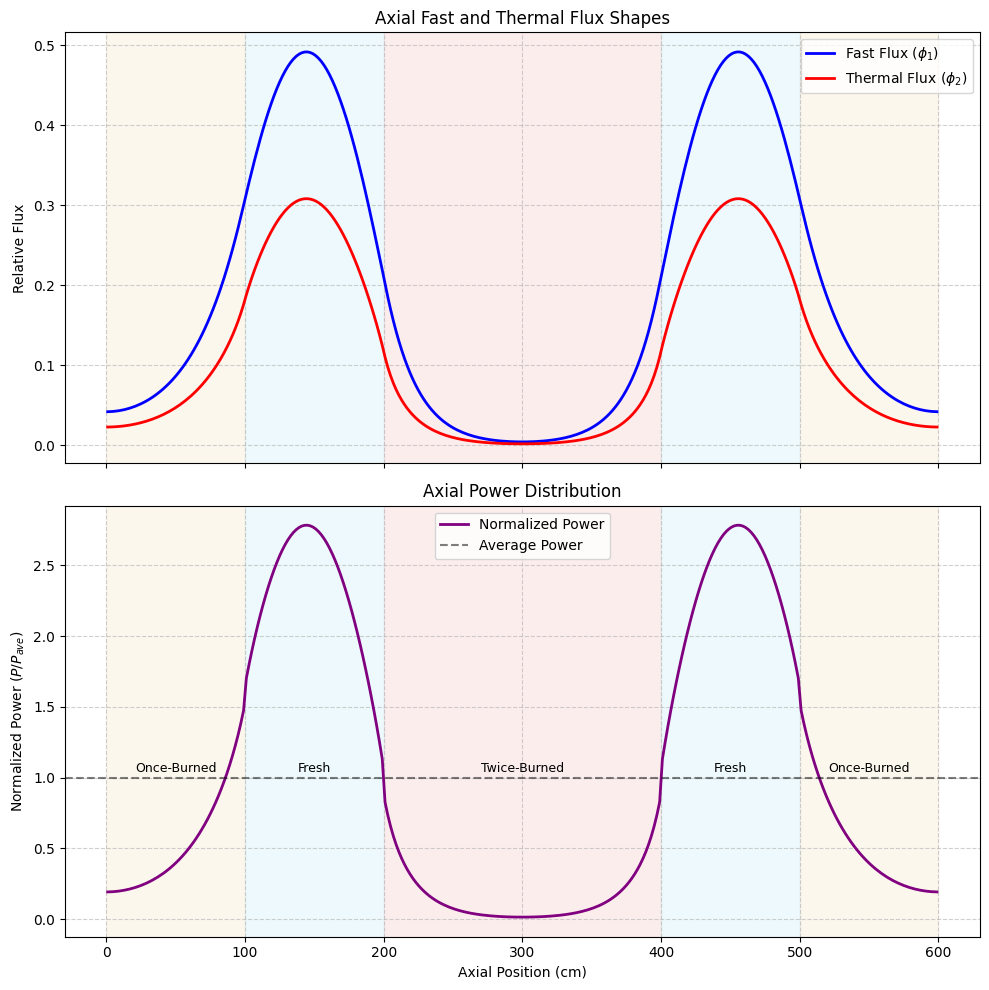

--- Core Calculation Results ---
k-effective: 1.09082
Power Peaking Factor: 2.84331
Target met? k > 1.05: True, PPF: < 1.15: False


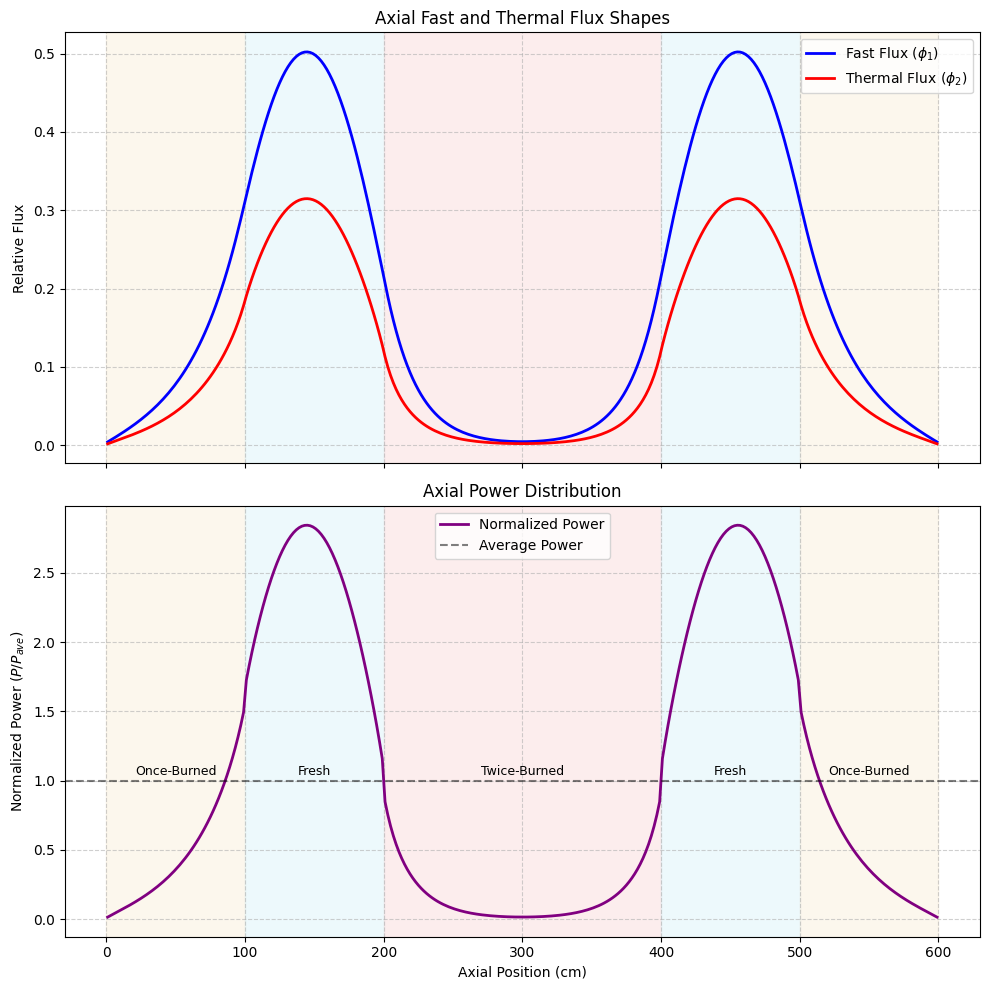

--- Core Calculation Results ---
k-effective: 1.17194
Power Peaking Factor: 3.44214
Target met? k > 1.05: True, PPF: < 1.15: False


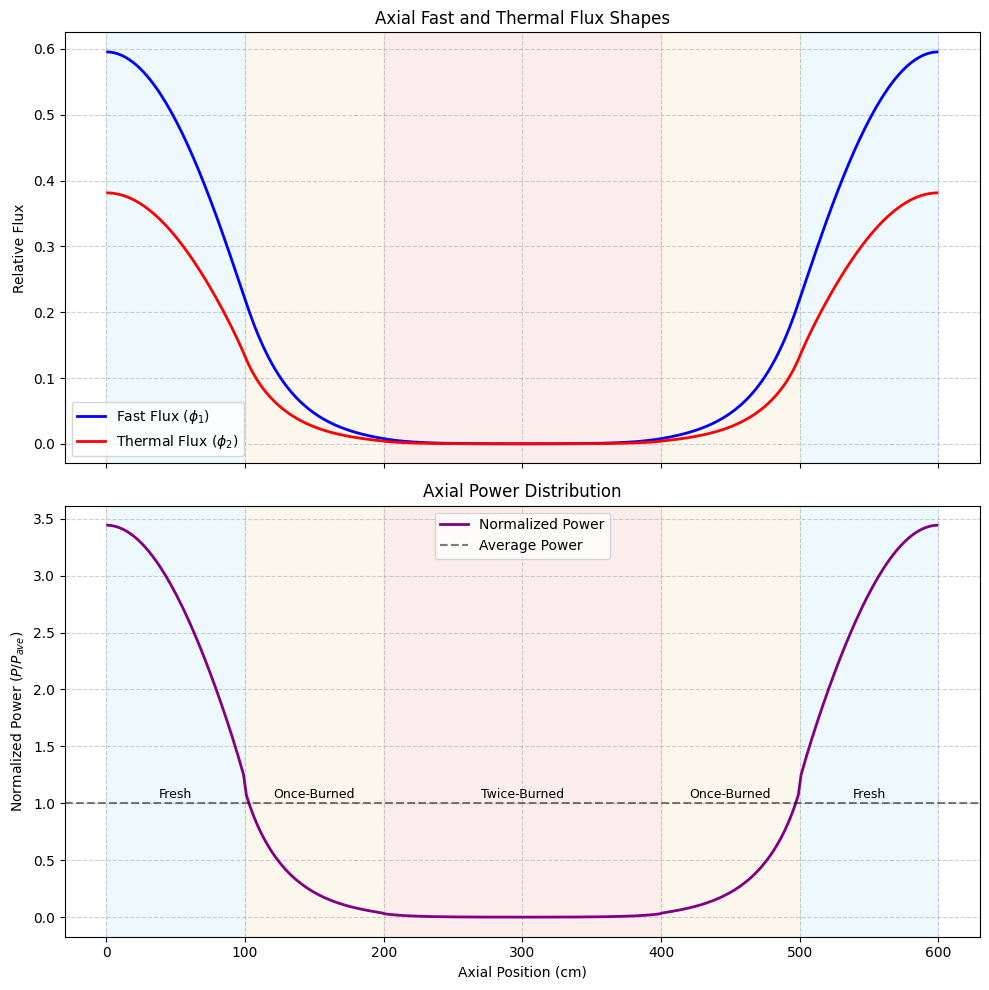

--- Core Calculation Results ---
k-effective: 1.05940
Power Peaking Factor: 3.13729
Target met? k > 1.05: True, PPF: < 1.15: False


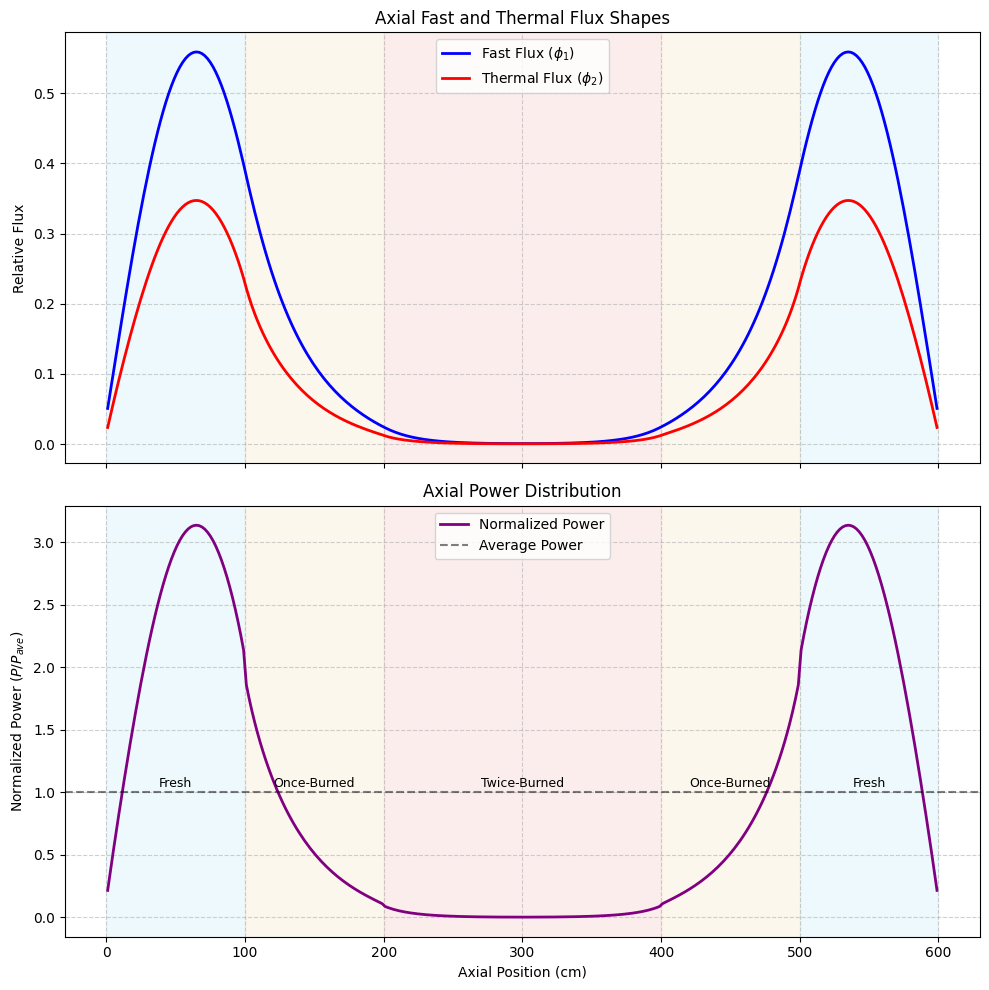

In [ ]:
# Fuel properties given in the table
fresh = {"D1": 1.55, "D2": 0.82, "Sa1": 0.0012, "Sa2": 0.0105, "Ss12": 0.0068, "nSf1": 0.00035, "nSf2": 0.0145}
once  = {"D1": 1.50, "D2": 0.80, "Sa1": 0.0016, "Sa2": 0.0125, "Ss12": 0.0065, "nSf1": 0.00045, "nSf2": 0.0132}
twice = {"D1": 1.45, "D2": 0.78, "Sa1": 0.0021, "Sa2": 0.0155, "Ss12": 0.0062, "nSf1": 0.00055, "nSf2": 0.0115}

# Define Core layout - Standard
core_layout_1 = [
    make_region(fresh, 100, 50, "Fresh"),
    make_region(once, 100, 50, "Once-Burned"),
    make_region(twice, 200, 100, "Twice-Burned"),
    make_region(once, 100, 50, "Once-Burned"),
    make_region(fresh, 100, 50, "Fresh")
]

core_layout_2 = [
    make_region(once, 100, 50, "Once-Burned"),
    make_region(fresh, 100, 50, "Fresh"),
    make_region(twice, 200, 100, "Twice-Burned"),
    make_region(fresh, 100, 50, "Fresh"),
    make_region(once, 100, 50, "Once-Burned")
]

# Now ima try some freaky stuff to make things spicier and see if I can get a better PPF and Keff by playing with the layout more.

core_layout_3 = [

    make_region(once,   50,  25, "Once-Burned"),   # Left Outer Edge
    make_region(fresh,  50,  25, "Fresh"),
    make_region(once,   50,  25, "Once-Burned"),
    make_region(fresh,  50,  25, "Fresh"),
    
    make_region(twice,  200, 100, "Twice-Burned"), # Center Peak Suppressor
    
    make_region(fresh,  50,  25, "Fresh"),
    make_region(once,   50,  25, "Once-Burned"),
    make_region(fresh,  50,  25, "Fresh"),
    make_region(once,   50,  25, "Once-Burned")    # Right Outer Edge
]

core_layout_4 = [

    make_region(twice,  50, 25, "Twice-Burned"),   # Shaved outer edge blanket
    make_region(once,  100, 50, "Once-Burned"),    # Intermediate zone
    make_region(fresh, 100, 50, "Fresh"),          # Shifted outward driver
    
    make_region(twice, 100, 50, "Twice-Burned"),   # Maximized central suppressor (100cm)
    
    make_region(fresh, 100, 50, "Fresh"),          # Shifted outward driver
    make_region(once,  100, 50, "Once-Burned"),    # Intermediate zone
    make_region(twice,  50, 25, "Twice-Burned")    # Shaved outer edge blanket
]

core_layout_5 = [
    make_region(twice,  80, 40, "Twice-Burned"),   # Shaved outer edge blanket
    make_region(once,  100, 50, "Once-Burned"),    # Intermediate zone
    make_region(fresh, 100, 50, "Fresh"),          # Shifted outward driver
    
    make_region(twice, 40, 30, "Twice-Burned"),   # Maximized central suppressor (100cm)
    
    make_region(fresh, 100, 50, "Fresh"),          # Shifted outward driver
    make_region(once,  100, 50, "Once-Burned"),    # Intermediate zone
    make_region(twice,  80, 40, "Twice-Burned")    # Shaved outer edge blanket
]


# Try a TOFFOTTOFFOT layout for a different PPF and Keff?
# 

# Testing different core layouts and comparing results
# x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels = solve_two_group_k_eigenvalue(core_layout_1)
# output_results(x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels, core_layout_1)

x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels = solve_two_group_k_eigenvalue(core_layout_2, bc_type="reflecting")
output_results(x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels, core_layout_2)

x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels = solve_two_group_k_eigenvalue(core_layout_2, bc_type="vacuum")
output_results(x, phi1, phi2, k, k_history, iters, nSf1, nSf2, labels, core_layout_2)


